# Visualization of model output

Plots initial dilution of the plume, surface current at the discharge, wind at the discharge.

In [ ]:
from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

from modules import read_files as read
from modules import helpers
from modules import ADCP as custom
import matplotlib.pyplot as plt
from modules import read_files as rd 
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import glob
import xarray as xr
import os

### Initial dilution of the plume

In [ ]:
# read file and compute min and mean values
jet_A = rd.get_mohid_timeseries_1_file('../../data/model_output/JET/WWTP_A.jet')
print('Min dilution :', jet_A['Dilution'].min())
print('Mean dilution :', jet_A['Dilution'].mean())



Min dilution : 49.0
Mean dilution : 76.08934131736527


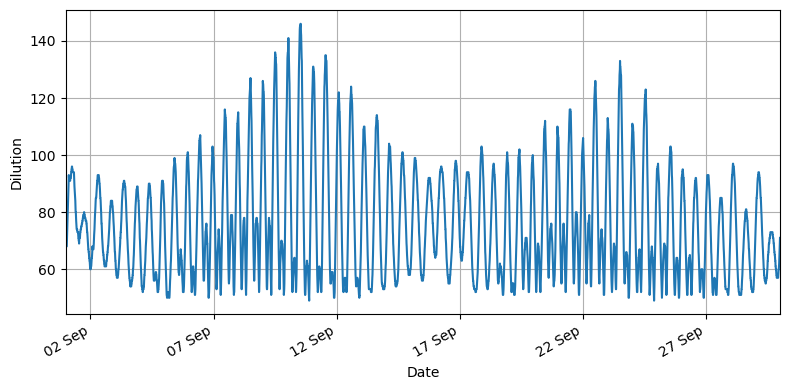

In [ ]:
# visualize results
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    jet_A.index,
    jet_A['Dilution']
)

ax.set_ylabel("Dilution")
ax.set_xlabel("Date")
ax.grid(True)

# X-axis formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_xlim(
    jet_A.index.min(),
    jet_A.index.max()
)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Surface current at discharge

In [ ]:
# read files
dir_model_output = '../../data/model_output/Lagrangian'
folder_name = 'discharge'
base_name = 'layer' 

all_results = read.read_files(base_dir=dir_model_output, folder=folder_name, name=base_name)


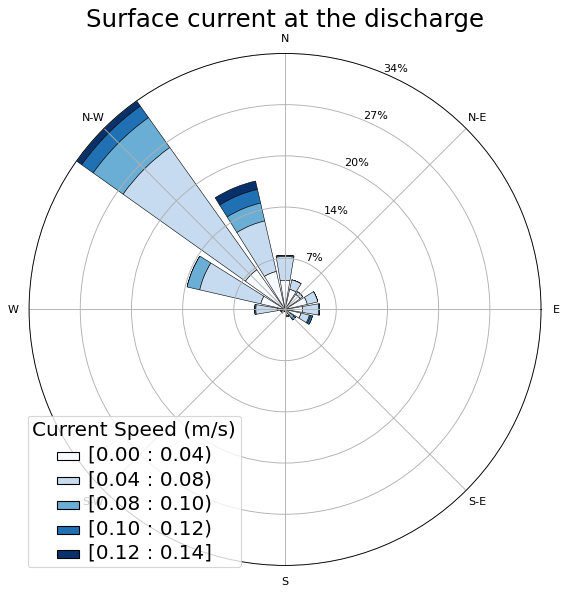

<WindroseAxes: title={'center': 'Surface current at the discharge'}>

In [ ]:
# visualize results
all_results[34]

bins_model=[0, 0.04, 0.08, 0.10, 0.12] 
labels_model = [
    '[0.00 : 0.04)',
    '[0.04 : 0.08)',
    '[0.08 : 0.10)',
    '[0.10 : 0.12)',
    '[0.12 : 0.14]']


custom.plot_rose(
    all_results[34]['velocity_direction'],
    all_results[34]['velocity_modulus'],
    bins=bins_model,
    labels = labels_model,
    title='Surface current at the discharge',
    cmap='Blues',
    outdir='../results/model_analysis/surface_current_rose.png')

### Wind at discharge

In [ ]:
# read file
dir_model = '../../data/model_output/Lagrangian/Atmosphere_1.hdf5'      # directory to model output data
outdir_model = '../../data/model_output/Lagrangian//'  
# read and convert model output files
t, dates = read.MOHIDHdf5toNetcdf_wind(dir_model, outdir=outdir_model)

# concat files with time
files = sorted(
    glob.glob(os.path.join(outdir_model, 'Atmosphere_*.nc'))
)
datasets = [xr.open_dataset(f) for f in files]

# Stack them along a 'time' dimension
ds_model = xr.concat(datasets, dim='time')

# Close the underlying file handles now that data is in memory
for d in datasets:
    d.close()

# assign coordinate according to dates
with h5py.File(dir_model, 'r') as f:
    time_keys = sorted(f['Time'].keys())
    real_dates = []
    for k in time_keys:
        arr = f['Time'][k][:].ravel().astype(float)  
        y, m, d, H, M, S = arr[:6]
        real_dates.append(pd.Timestamp(int(y), int(m), int(d),
                                       int(H), int(M), int(round(S))))

ds_model = ds_model.assign_coords(time=('time', real_dates))

ds_model = ds_model.sel(lat=28.174497, lon=-16.820003)

In [ ]:
# Compute modulus and direction
modulus = np.sqrt(ds_model['wind velocity X']**2 + ds_model['wind velocity Y']**2)
direction = (np.degrees(np.arctan2(ds_model['wind velocity X'], ds_model['wind velocity Y']))) % 360


wind = pd.DataFrame({
    'date': ds_model.time.values,
    'wind_modulus' : modulus.values,   
    'wind_direction' : direction.values    

})
wind = wind.set_index('date')

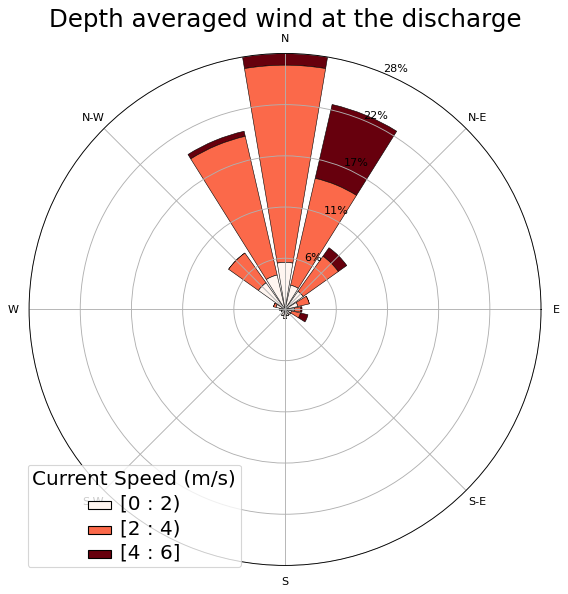

<WindroseAxes: title={'center': 'Depth averaged wind at the discharge'}>

In [ ]:
# visualize results
bins_model=[0, 2, 4] 
labels_model = [
    '[0 : 2)',
    '[2 : 4)',
    '[4 : 6]']

custom.plot_rose(
    wind['wind_direction'],
    wind['wind_modulus'],
    bins=bins_model,
    labels = labels_model,
    title='Wind at the discharge',
    cmap='Reds',
    outdir='../results/model_analysis/wind_rose.png')